# Week 6 - Bivariate Analysis, part 2

# 1. Lesson: no lesson this week

# 2. Weekly graph question

Suppose you wanted to show the nitrate and phosphate level in a water sample.  What are the advantages and disadvantages of showing this as an area plot, as opposed to two separate line graphs?  How would you adjust the graphs shown to improve the presentation?

### Response ###

The advantages of showing this as an area plot are:
- It shows the combined total in one view
- It's easier to see the relationship between nitrate and phosphate levels when there are in the same graph
- It's more visible as everything is in the one chart. There's no need to go elsewhere to see the full story of the nitrate and phosphate levels

The disadvantages include:
- In this graph specifically, there legend should be changed to label nitrate and phosphate for their assigned colors. The X and Y axis are named appropriately so the view knows which is for Nitrate and which if for Phosphate.
- It's difficult to compare the exact values between nitrate and phosphate. The other two graphs show more detail on what the values are (still not exact).

To improve presentation:
- Add the appropriate labels and titles to all of the graphs.
- Add small dots to the line graphs for easier visibility on the values.
- Add gridlines to the line graphs.

In [29]:
import numpy as np
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

Text(0, 0.5, 'Nitrate level (% of eutrophic value)')

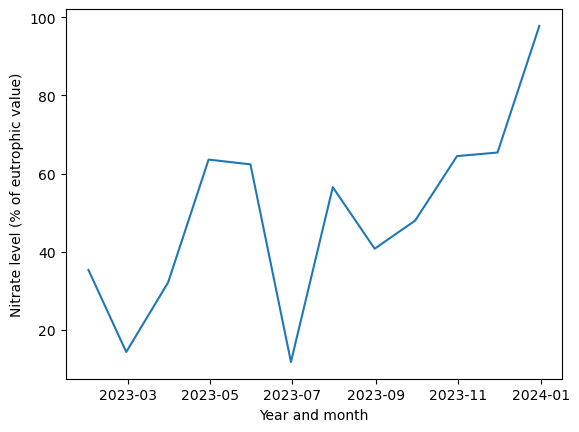

In [5]:
numdates = 12
np.random.seed(0)
time_series = 100 * (np.random.normal(size = numdates) / 5 + np.arange(numdates) / 16)
datearray = pd.date_range(start='2023/01/01', end='2024/01/01', freq='ME')
ax = sns.lineplot(x = datearray, y = time_series)
ax.set_xlabel("Year and month")
ax.set_ylabel("Nitrate level (% of eutrophic value)")

Text(0, 0.5, 'Phosphate level (% of eutrophic value)')

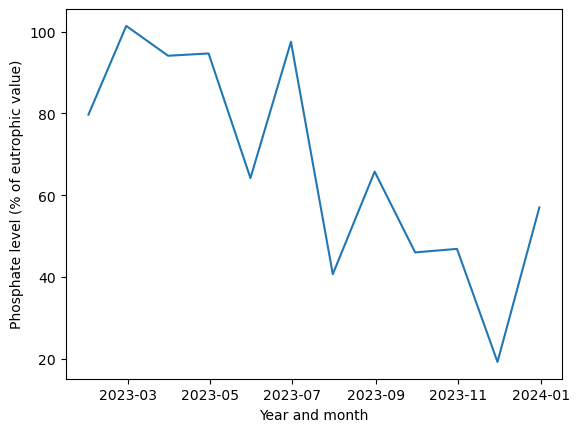

In [6]:
np.random.seed(1)
time_series_2 =  100 * (1 - (np.random.normal(size = numdates) / 8 + np.arange(numdates) / 16))
datearray = pd.date_range(start='2023/01/01', end='2024/01/01', freq='ME')
ax = sns.lineplot(x = datearray, y = time_series_2)
ax.set_xlabel("Year and month")
ax.set_ylabel("Phosphate level (% of eutrophic value)")

<Axes: >

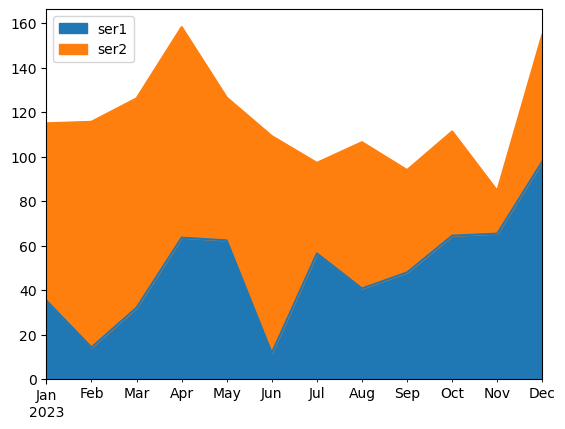

In [7]:
df = pd.DataFrame({'ser1': time_series, 'ser2': time_series_2}, index = datearray)
df.plot.area()

In [9]:
df_stream = pd.read_csv('movie_tv_stream_cv3.csv')
df_box_office = pd.read_csv('movie_box_office_cv2.csv')

## Streaming Movies and TV Dataset

In [25]:
# CHECKING ALL OF THE TYPES IN THE DATASET
with pd.option_context('display.max_rows', None):
    print(df_stream.dtypes)

movie_or_tv_show         object
title                    object
director                 object
cast                     object
country                  object
date_added_platform       Int64
release_year              int64
duration_seconds         object
genre_type               object
description              object
channel_streaming        object
no_genre                  int64
action                    int64
actionadventure           int64
adult                     int64
adventure                 int64
animals                   int64
animation                 int64
anime                     int64
anthology                 int64
arthouse                  int64
arts                      int64
biographical              int64
black                     int64
british                   int64
buddy                     int64
cartoons                  int64
children                  int64
classic                   int64
classics                  int64
comedies                  int64
comedy  

In [18]:
# HERE UPDATING FOR CORRELATION ANALYSIS
df_stream['year_added_platform'] = pd.to_numeric(df_stream['year_added_platform'], errors='coerce').astype('Int64')
df_stream['tv_season'] = pd.to_numeric(df_stream['tv_season'], errors='coerce').astype('Int64')
df_stream['runtime_minutes'] = pd.to_numeric(df_stream['runtime_minutes'], errors='coerce').astype('Int64')
df_stream['month_added_platform'] = pd.to_numeric(df_stream['month_added_platform'], errors='coerce').astype('Int64')
df_stream['date_added_platform'] = pd.to_numeric(df_stream['date_added_platform'], errors='coerce').astype('Int64')

In [19]:
# VERIFICATION THAT THE VALUES IN THE COLUMNS ABOVE HAVE BEEN CHANGED TO INTEGERS
with pd.option_context('display.max_rows', None):
    print(df_stream.dtypes)

movie_or_tv_show         object
title                    object
director                 object
cast                     object
country                  object
date_added_platform       Int64
release_year              int64
duration_seconds         object
genre_type               object
description              object
channel_streaming        object
no_genre                  int64
action                    int64
actionadventure           int64
adult                     int64
adventure                 int64
animals                   int64
animation                 int64
anime                     int64
anthology                 int64
arthouse                  int64
arts                      int64
biographical              int64
black                     int64
british                   int64
buddy                     int64
cartoons                  int64
children                  int64
classic                   int64
classics                  int64
comedies                  int64
comedy  

The strongest correlation is release year to year added at 0.10. 
The weakest correlation is runtime_minutes against all of the numerical columns. (More thorough details in the conclusion section)

In [26]:
# STREAMING — CORRELATIONS BETWEEN NUMERICAL VARIABLES
stream_numeric = df_stream[['release_year', 'runtime_minutes', 
                             'year_added_platform', 'month_added_platform', 'tv_season']]

print("Streaming Dataset Correlations:")
print(stream_numeric.corr().round(2))

Streaming Dataset Correlations:
                      release_year  runtime_minutes  year_added_platform  \
release_year                  1.00             0.02                 0.10   
runtime_minutes               0.02             1.00                 0.06   
year_added_platform           0.10             0.06                 1.00   
month_added_platform         -0.11            -0.06                -0.12   
tv_season                    -0.26              NaN                -0.04   

                      month_added_platform  tv_season  
release_year                         -0.11      -0.26  
runtime_minutes                      -0.06        NaN  
year_added_platform                  -0.12      -0.04  
month_added_platform                  1.00      -0.03  
tv_season                            -0.03       1.00  


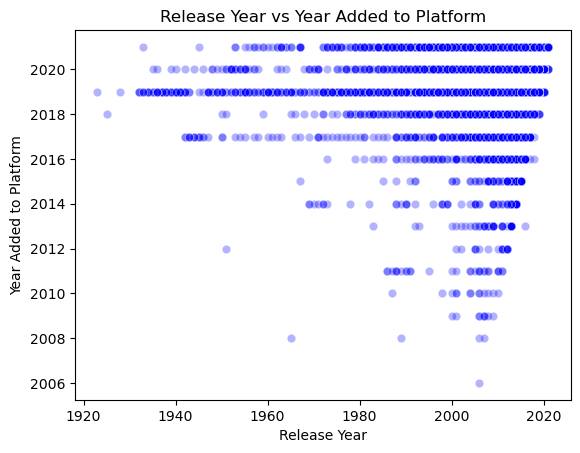

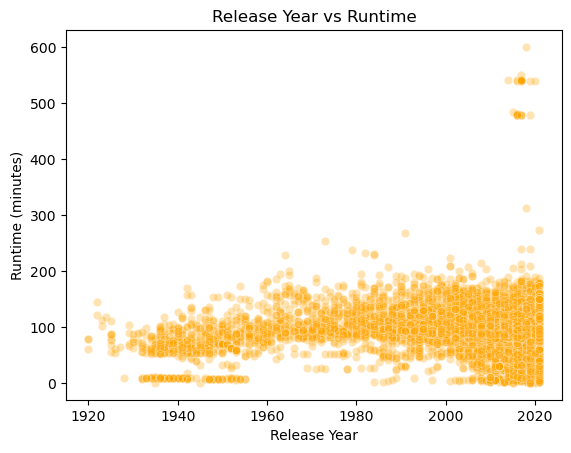

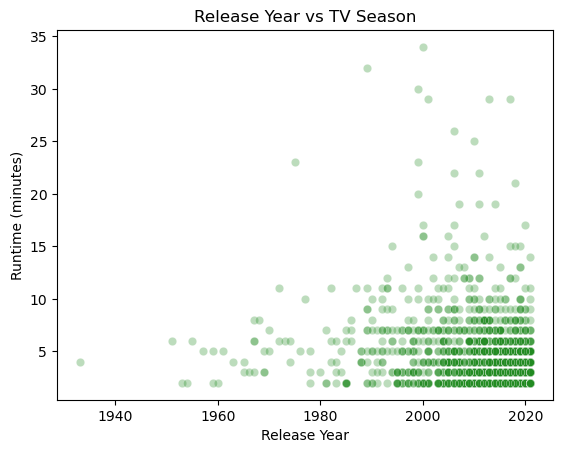

In [ ]:
# SCATTER: RELEASE YEAR VS YEAR ADDED TO PLATFORM
sns.scatterplot(data=df_stream, x='release_year', 
                y='year_added_platform', alpha=0.3, color='blue')
plt.title('Release Year vs Year Added to Platform')
plt.xlabel('Release Year')
plt.ylabel('Year Added to Platform')
plt.show()

# SCATTER: RELEASE YEAR VS MOVIE RUN TIME IN MINUTES
sns.scatterplot(data=df_stream, x='release_year', 
                y='runtime_minutes', alpha=0.3, color='orange')
plt.title('Release Year vs Runtime')
plt.xlabel('Release Year')
plt.ylabel('Runtime (minutes)')
plt.show()

# SCATTER: RELEASE YEAR VS NUMBER OF TV SEASONS
sns.scatterplot(data=df_stream, x='release_year', 
                y='tv_season', alpha=0.3, color='forestgreen')
plt.title('Release Year vs TV Season')
plt.xlabel('Release Year')
plt.ylabel('Runtime (minutes)')
plt.show()

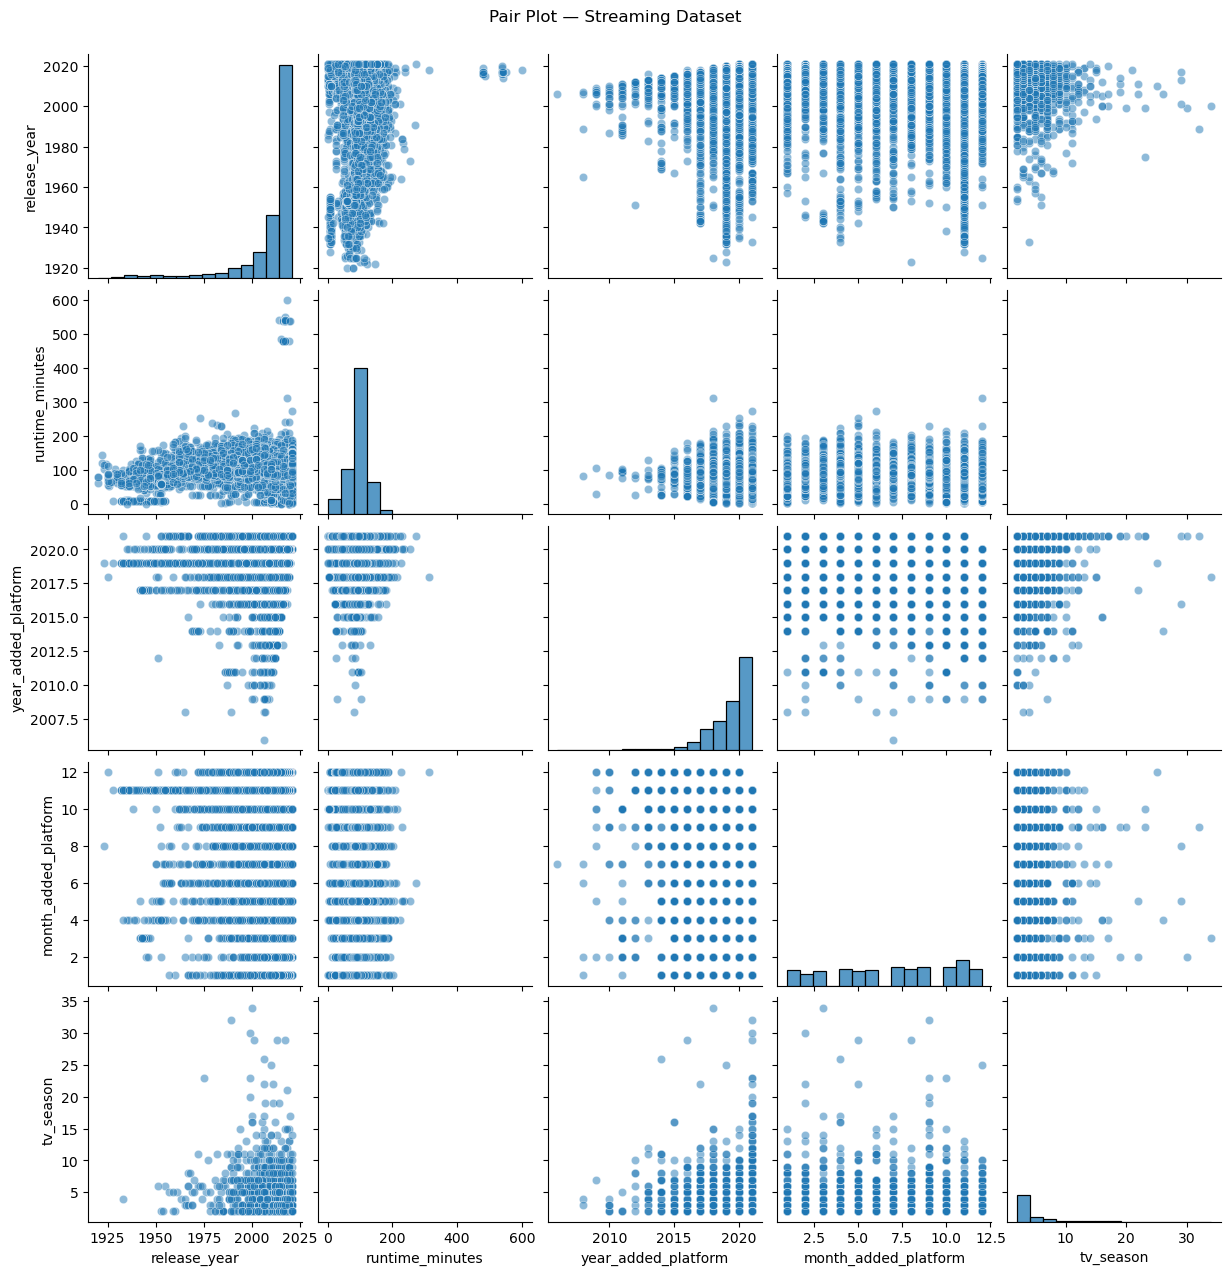

In [39]:
sns.pairplot(stream_numeric, plot_kws={'alpha': 0.5}, diag_kws={'bins':15})
plt.suptitle('Pair Plot — Streaming Dataset', y=1.02)
plt.show()

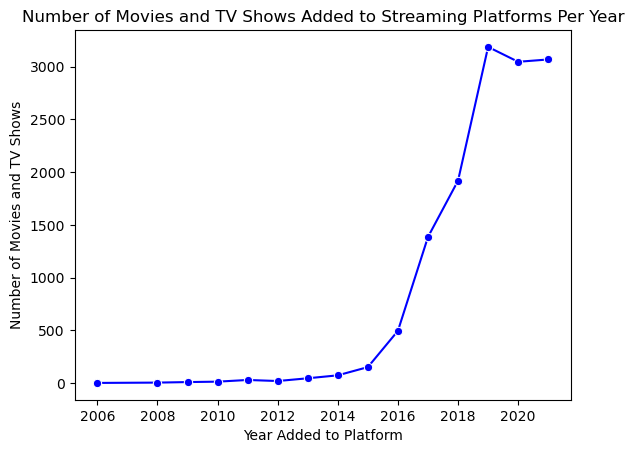

In [48]:
additions_per_year = df_stream.groupby('year_added_platform')['title'].count()

sns.lineplot(x=additions_per_year.index, y=additions_per_year.values, 
             marker='o', color='blue')
plt.title('Number of Movies and TV Shows Added to Streaming Platforms Per Year')
plt.xlabel('Year Added to Platform')
plt.ylabel('Number of Movies and TV Shows')
plt.show()

- Find correlations between pairs of variables.

- Draw scatterplots, especially when the correlation is large.

- Draw pairplots.

- Draw line graphs and/or area graphs when there is date or time data together with numerical data.

### Conclusions:

- **Explain what conclusions you would draw from this analysis: are the data what you expect?  Are the data likely to be usable?  If the data are not useable, find some new data!**
  The data is useful and most of the data is what I expected, including the extremely jump of streaming services and the adding of content to the platforms.

- **Do you see any outliers?  (Data points that are far from the rest of the data)**
  There is content with over 300 minutes. Most of these are actually meditation music, sleep sounds, relaxing campfires, and other soothing sounds.

- **Are any data items highly correlated with each other, suggesting that they are redundant?**
  The correlations are very weak between all of the numerical values, with the highest correlation being 0.26. This relationship is between the release year and tv season. This correlation is also negative. This suggests that older TV shows tend to have more seasons (which was one of my hypotheses) due to the debuts on national television and accumulating more seasons over time compared to streaming originals. 

  There is no correlation beteen runtime_minutes and tv_season because the runtime_minutes is only for movies while tv_season is only for tv shows. The two columns never appear in the same row. 

  The overall lack of strong correlation relationships indicates there an independence across all of these numerical values, which was actually surprising to me. I assumed that would be more of a correlation between year added to the streaming service versus year of the movie/tv show release.

- **For the line plots, do you see a trend or pattern over time?  Does this suggest that the data are changing over time (drifting) in such a way as to invalidate comparisons?**
  Shown is the incredible jump in content that was added to the platforms as a whole by year. 

- **Can you think of any confounding variables?  (Third variables that could explain any correlations between other variables.  These third variables may or may not be reported in the dataset.)**
  Because there is barely a relationship between the numerical values in the dataset, quite weak, I don't believe there is a third confound variable.

## Movie Box Office ##

### Here are some types of analysis you can do:

- Find correlations between pairs of variables.

- Draw scatterplots, especially when the correlation is large.

- Draw pairplots.

- Draw line graphs and/or area graphs when there is date or time data together with numerical data.

In [53]:
# CHECKING ALL OF THE TYPES IN THE DATASET
with pd.option_context('display.max_rows', None):
    print(df_box_office.dtypes)

Rank                          int64
Movie Title                  object
$Worldwide                  float64
$Domestic                   float64
Domestic %                  float64
$Foreign                    float64
Foreign %                   float64
Year                          int64
Genres                       object
Rating                      float64
Vote_Count                  float64
Original_Language            object
Production_Countries         object
Action                        int64
Adventure                     int64
Animation                     int64
Comedy                        int64
Crime                         int64
Documentary                   int64
Drama                         int64
Family                        int64
Fantasy                       int64
History                       int64
Horror                        int64
Music                         int64
Mystery                       int64
Romance                       int64
Science Fiction             

In [54]:
# STREAMING — CORRELATIONS BETWEEN NUMERICAL VARIABLES
stream_numeric = df_box_office[['$Worldwide', '$Domestic', 
                             '$Foreign', 'Year', 'Rating', "Vote_Count"]]

print("Streaming Dataset Correlations:")
print(stream_numeric.corr().round(2))

Streaming Dataset Correlations:
            $Worldwide  $Domestic  $Foreign  Year  Rating  Vote_Count
$Worldwide        1.00       0.92      0.97  0.06    0.18        0.72
$Domestic         0.92       1.00      0.80 -0.02    0.17        0.73
$Foreign          0.97       0.80      1.00  0.10    0.17        0.66
Year              0.06      -0.02      0.10  1.00    0.13       -0.01
Rating            0.18       0.17      0.17  0.13    1.00        0.31
Vote_Count        0.72       0.73      0.66 -0.01    0.31        1.00


- Explain what conclusions you would draw from this analysis: are the data what you expect?  Are the data likely to be usable?  If the data are not useable, find some new data!

- Do you see any outliers?  (Data points that are far from the rest of the data).

- Are any data items highly correlated with each other, suggesting that they are redundant?

- For the line plots, do you see a trend or pattern over time?  Does this suggest that the data are changing over time (drifting) in such a way as to invalidate comparisons?

- Can you think of any confounding variables?  (Third variables that could explain any correlations between other variables.  These third variables may or may not be reported in the dataset.)

# 4. Storytelling With Data plot

Reproduce any graph of your choice in p. 86-98 of the Storytelling With Data book as best you can.  (The second half of chapter three).  You do not have to get the exact data values right, just the overall look and feel.